<a href="https://colab.research.google.com/github/silviolima07/desafio_final/blob/main/desafio_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [170]:
df = pd.read_csv('/content/dataset_carros_brasil.csv')

In [171]:
df.head()

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda
0,Ford,EcoSport,2003.0,82624,Azul,Automático,Flex,4,52604.2
1,Hyundai,HB20S,2017.0,69260,Azul,Automático,Diesel,2,63219.0
2,Jeep,Renegade,2008.0,106493,Cinza,Manual,Gasolina,2,79710.4
3,Toyota,Corolla,2018.0,53570,Prata,Automático,Flex,2,99149.0
4,Ford,Ranger,2009.0,21643,Prata,Manual,Flex,2,68913.4


In [155]:
df.shape

(10000, 9)

### Checar dados ausentes

In [156]:
df.isna().sum()

,0
Marca,0
Modelo,0
Ano,100
Quilometragem,0
Cor,0
Cambio,0
Combustivel,0
Portas,0
Valor_Venda,0


### Identificar o ano mais frequente na base de dados.

In [157]:
mode_ano = df['Ano'].mode()[0]
df['Ano'].fillna(mode_ano, inplace=True)

### Checar o tipo dos dados

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          10000 non-null  object 
 1   Modelo         10000 non-null  object 
 2   Ano            10000 non-null  float64
 3   Quilometragem  10000 non-null  object 
 4   Cor            10000 non-null  object 
 5   Cambio         10000 non-null  object 
 6   Combustivel    10000 non-null  object 
 7   Portas         10000 non-null  int64  
 8   Valor_Venda    10000 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 703.3+ KB


### Converter o valor de Ano para inteiro.

In [159]:
df['Ano'] = df['Ano'].astype(int)

### Checar os valores em Quilometragem.

In [160]:
df['Quilometragem'].value_counts()

,count
Quilometragem,
erro_medicao,100
166373,3
124790,3
97491,3
118222,3
...,...
10301,1
124798,1
186073,1


### Existem 100 registros identificados como 'erro_medicao'.
### Estas linhas serão removidas.

In [161]:
df['Quilometragem'] = df['Quilometragem'].replace('erro_medicao', np.nan)
df['Quilometragem'] = pd.to_numeric(df['Quilometragem'])
df = df.dropna(subset=['Quilometragem'])

In [162]:
df['Quilometragem'].value_counts()

,count
Quilometragem,
645.0,3
97491.0,3
118222.0,3
124790.0,3
166373.0,3
...,...
10301.0,1
124798.0,1
186073.0,1


In [144]:
# Calcula os limites do IQR
def remove_outliers(df, col):
    print(f'\nChecar outliers de {col}')
    print('Antes:', df.shape)
    Q1 = df[col].quantile(0.25) #calcula o quartil de 25% (valor abaixo do qual estão 25% dos dados ordenados)
    Q3 = df[col].quantile(0.75) #calcula o quartil de 75% (valor abaixo do qual estão 75% dos dados ordenados)
    IQR = Q3 - Q1 #calcula o índice interquartil

    limite_inferior = Q1 - 1.5 * IQR #calcula o o limite inferior
    limite_superior = Q3 + 1.5 * IQR #calcula o o limite superior
    df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]
    print('Depois:', df.shape)
    return df

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9801 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          9801 non-null   object 
 1   Modelo         9801 non-null   object 
 2   Ano            9801 non-null   int64  
 3   Quilometragem  9801 non-null   int64  
 4   Cor            9801 non-null   object 
 5   Cambio         9801 non-null   object 
 6   Combustivel    9801 non-null   object 
 7   Portas         9801 non-null   int64  
 8   Valor_Venda    9801 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 765.7+ KB


### Redefining `numeric_features` to include cleaned columns

In [164]:
numeric_features = df.select_dtypes(include=['int64', 'float64'])
target = 'Valor_Venda'
numeric_features = numeric_features.drop(columns=[target], errors='ignore')
display(numeric_features.head())

,Ano,Quilometragem,Portas
0,2003,82624.0,4
1,2017,69260.0,2
2,2008,106493.0,2
3,2018,53570.0,2
4,2009,21643.0,2


### Removendo outliers das variáveis numéricas (Ano, Quilometragem, Portas)

In [168]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Valor_Venda')

for col in numeric_features:
    df = remove_outliers(df, col)

# Exibir as informações do DataFrame após a remoção de outliers para verificar o novo shape e tipos de dados
df.info()


Checar outliers de Ano
Antes: (9686, 9)
Depois: (9686, 9)

Checar outliers de Quilometragem
Antes: (9686, 9)
Depois: (9686, 9)

Checar outliers de Portas
Antes: (9686, 9)
Depois: (9686, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 9686 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Marca          9686 non-null   object 
 1   Modelo         9686 non-null   object 
 2   Ano            9686 non-null   int64  
 3   Quilometragem  9686 non-null   float64
 4   Cor            9686 non-null   object 
 5   Cambio         9686 non-null   object 
 6   Combustivel    9686 non-null   object 
 7   Portas         9686 non-null   int64  
 8   Valor_Venda    9686 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 756.7+ KB


### Visualizando a distribuição das demais variáveis numéricas (Ano, Quilometragem, Portas)

Visualizando distribuição para a coluna: Ano


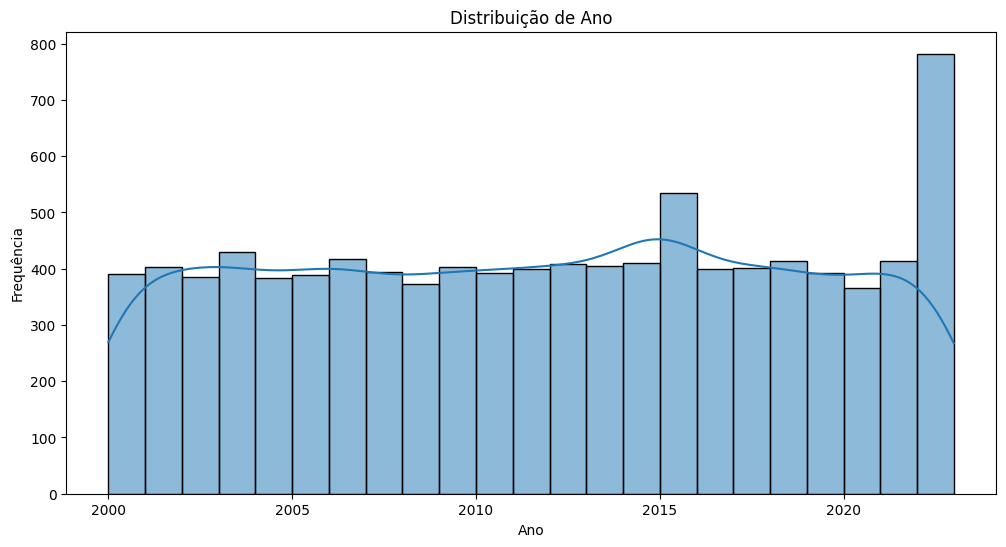

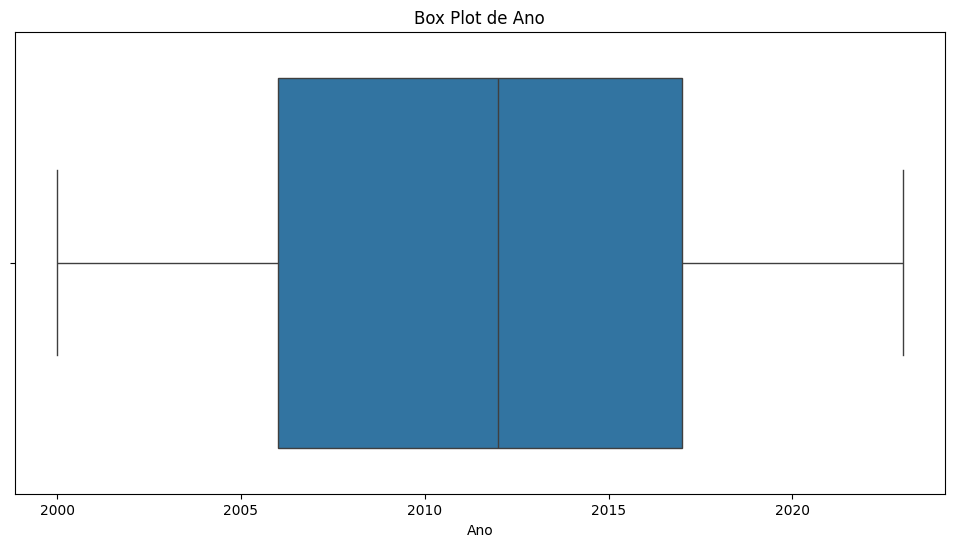

Visualizando distribuição para a coluna: Quilometragem


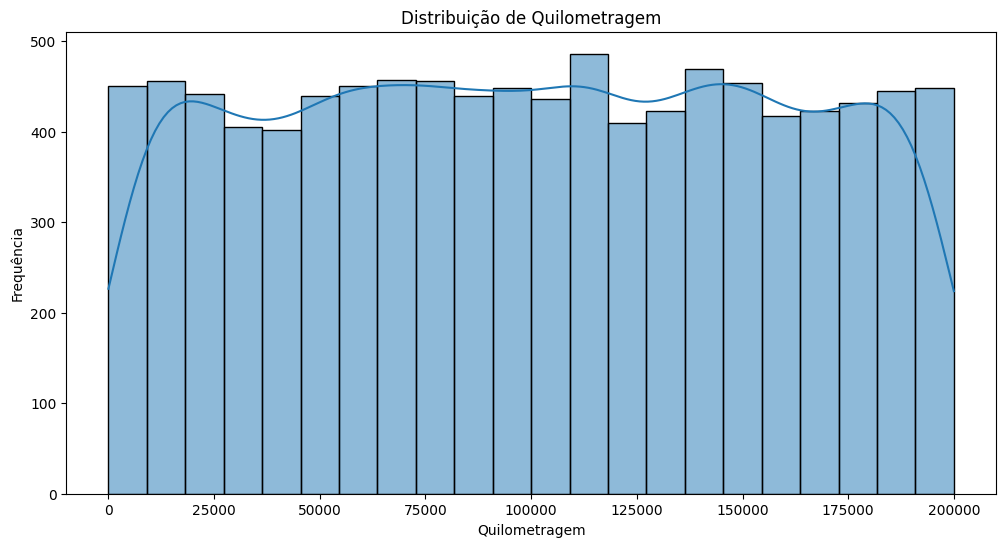

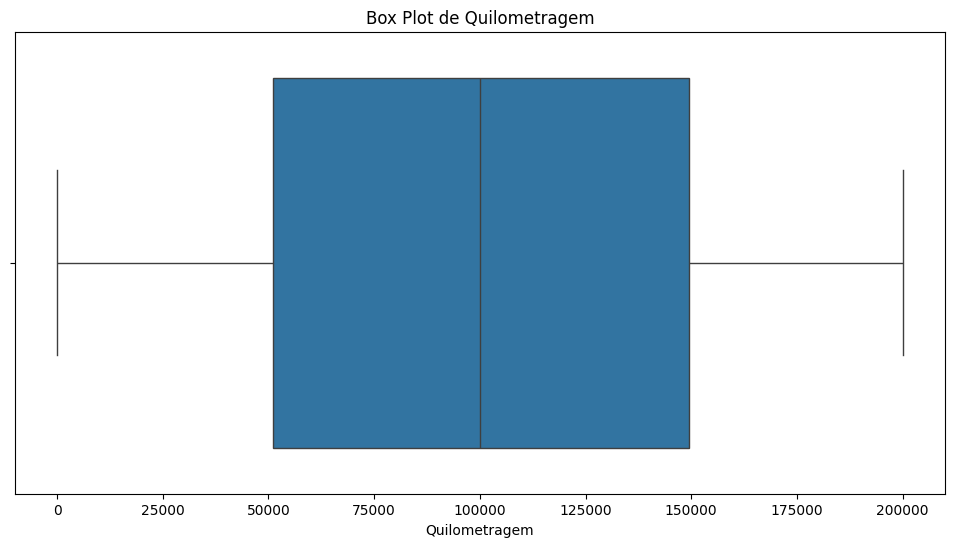

Visualizando distribuição para a coluna: Portas


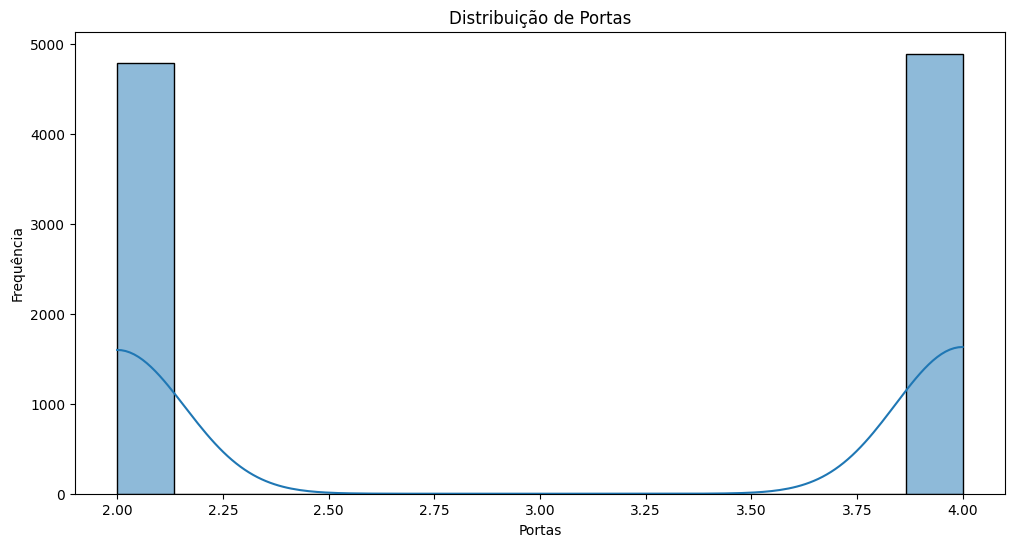

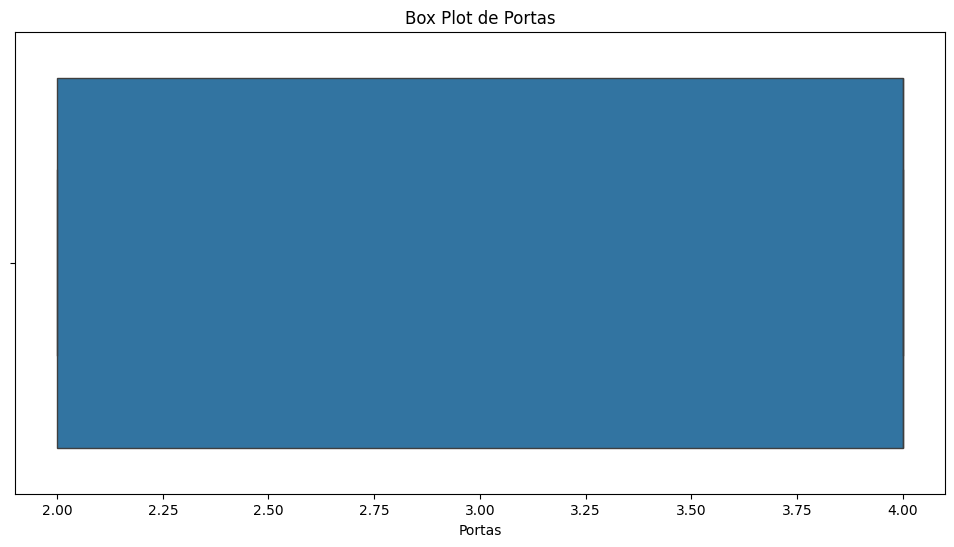

In [167]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Valor_Venda')

for col in numeric_features:
    print(f'Visualizando distribuição para a coluna: {col}')
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot de {col}')
    plt.xlabel(col)
    plt.show()

### Removendo outliers da variável alvo `Valor_Venda`

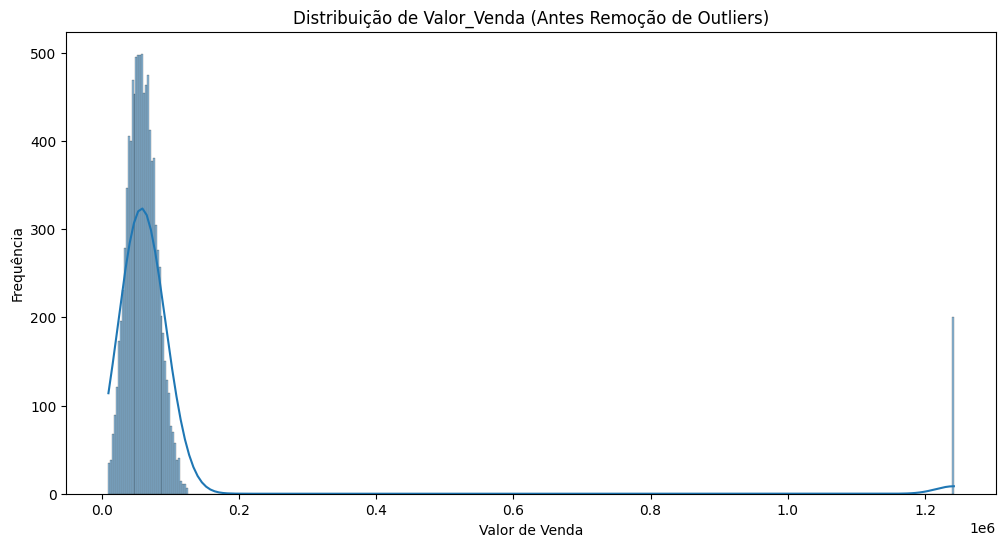

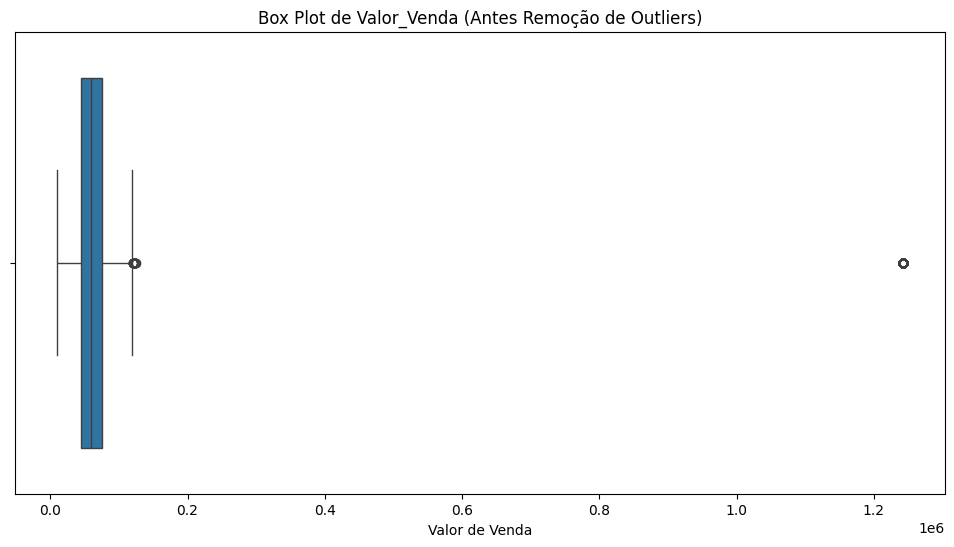

In [173]:

# Visualize a distribuição antes da  remoção de outliers
plt.figure(figsize=(12, 6))
sns.histplot(df['Valor_Venda'], kde=True)
plt.title('Distribuição de Valor_Venda (Antes Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Valor_Venda'])
plt.title('Box Plot de Valor_Venda (Antes Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.show()


Checar outliers de Valor_Venda
Antes: (10000, 9)
Depois: (9783, 9)


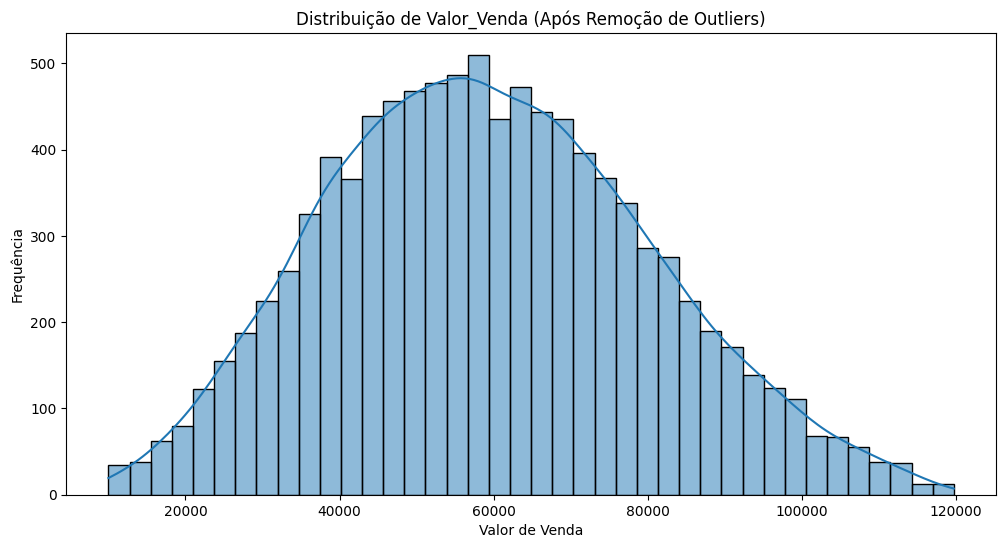

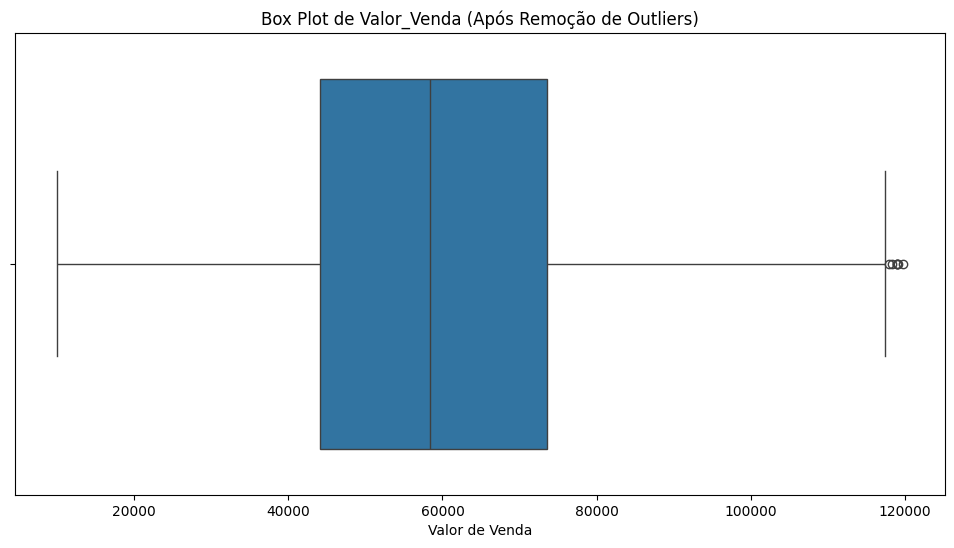

In [174]:
df = remove_outliers(df, 'Valor_Venda')

# Visualize a distribuição novamente após a remoção de outliers
plt.figure(figsize=(12, 6))
sns.histplot(df['Valor_Venda'], kde=True)
plt.title('Distribuição de Valor_Venda (Após Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Valor_Venda'])
plt.title('Box Plot de Valor_Venda (Após Remoção de Outliers)')
plt.xlabel('Valor de Venda')
plt.show()

### Visualizar a distribuição da variável alvo `Valor_Venda`

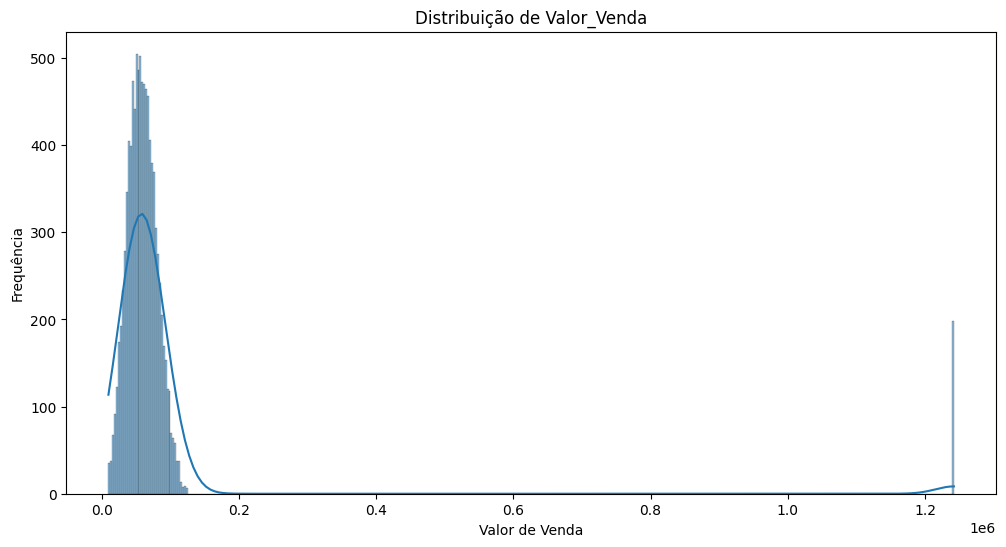

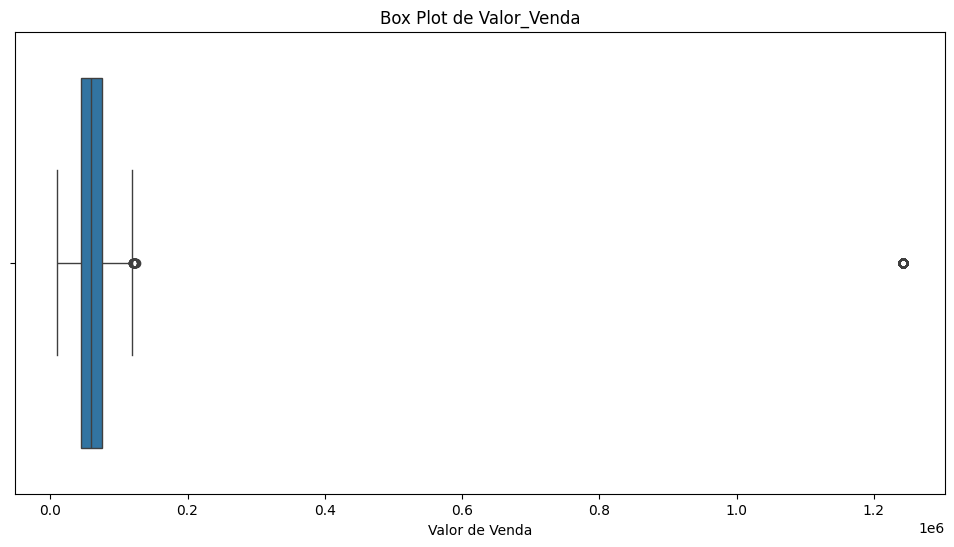

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['Valor_Venda'], kde=True)
plt.title('Distribuição de Valor_Venda')
plt.xlabel('Valor de Venda')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Valor_Venda'])
plt.title('Box Plot de Valor_Venda')
plt.xlabel('Valor de Venda')
plt.show()

In [138]:
df['Ano'].info()

<class 'pandas.core.series.Series'>
Index: 9801 entries, 0 to 9999
Series name: Ano
Non-Null Count  Dtype  
--------------  -----  
9801 non-null   float64
dtypes: float64(1)
memory usage: 153.1 KB


In [169]:
max_por_ano = df.groupby('Ano')['Valor_Venda'].max()
print(max_por_ano)

Ano
2000     90189.2
2001     89881.4
2002     96018.8
2003     90829.6
2004     96439.8
2005     99232.4
2006     99311.0
2007     95470.2
2008    102648.6
2009    106318.0
2010    108623.6
2011    109104.6
2012    107693.4
2013    109763.4
2014    112673.8
2015    113858.8
2016    112556.2
2017    114377.4
2018    116321.4
2019    117422.6
2020    115709.4
2021    119698.4
2022    118911.8
2023    119150.8
Name: Valor_Venda, dtype: float64


,Ano,Portas,Valor_Venda
count,404.0,404.000000,4.040000e+02
mean,2010.0,3.084158,8.898574e+04
std,0.0,0.997688,1.939710e+05
min,2010.0,2.000000,2.147680e+04
25%,2010.0,2.000000,4.388620e+04
50%,2010.0,4.000000,5.615900e+04
75%,2010.0,4.000000,7.091480e+04
max,2010.0,4.000000,1.241962e+06
